In [1]:
import numpy as np
windows = np.load("../data/windows.npy")
print(windows.shape)

(900, 23, 1024)


In [2]:
first_window = windows[0]
print(first_window.shape)

(23, 1024)


In [3]:
channel_1 = first_window[0]
print(channel_1.shape)

(1024,)


In [4]:
mean_value = np.mean(channel_1)
print("Mean =", mean_value)

Mean = 2.113282711041205e-05


In [5]:
std_value = np.std(channel_1)
print("Standard Deviation =", std_value)

Standard Deviation = 6.099746129634311e-05


In [6]:
variance = np.var(channel_1)
print("Variance =", variance)

Variance = 3.7206902845988755e-09


In [7]:
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq

In [8]:
 sfreq = 256

In [9]:
N = len(channel_1)
T = 1 / sfreq

print("Number of Sample =", N)
print("Sampling Interval =", T)

Number of Sample = 1024
Sampling Interval = 0.00390625


In [10]:
yf = fft(channel_1)
xf = fftfreq(N, T)

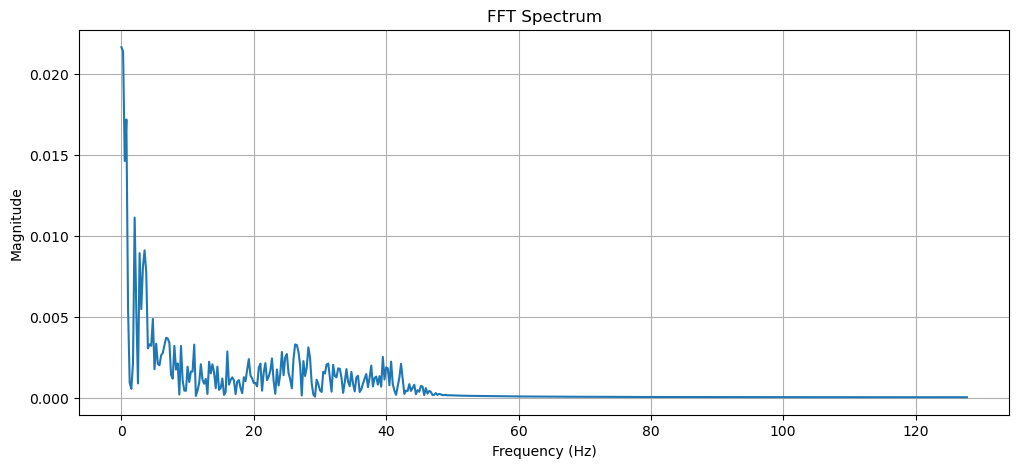

In [11]:
plt.figure(figsize=(12,5))
plt.plot(xf[:N//2], np.abs(yf[:N//2]))
plt.title("FFT Spectrum")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.grid(True)
plt.show()

In [12]:
from scipy.signal import welch
import matplotlib.pyplot as plt

In [13]:
frequencies, psd = welch(
    channel_1, 
    fs=sfreq,
    nperseg=512
)

In [14]:
print("Frequency Shape :", frequencies.shape)
print("PSD Shape :", psd.shape)

Frequency Shape : (257,)
PSD Shape : (257,)


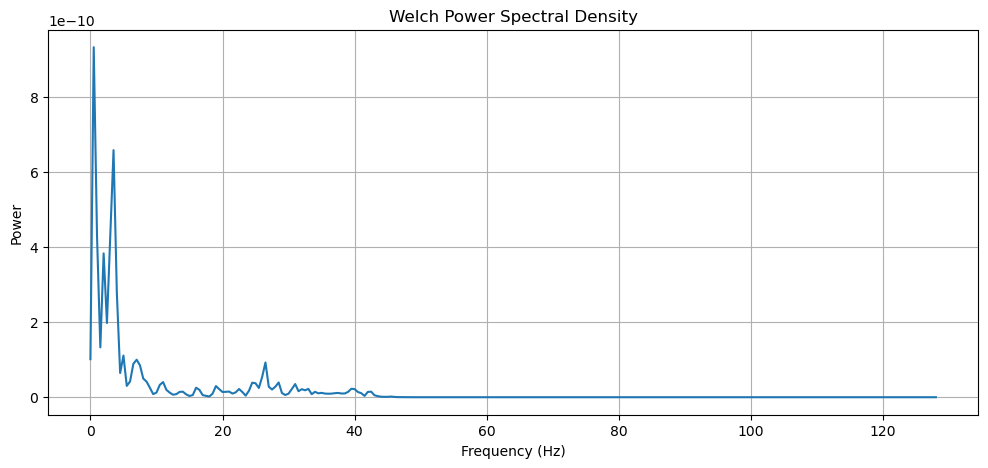

In [15]:
plt.figure(figsize=(12,5))
plt.plot(frequencies, psd)
plt.title("Welch Power Spectral Density")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power")
plt.grid(True)
plt.show()

In [16]:
import numpy as np
def bandpower(frequencies, psd, low, high):
    idx = np.logical_and(frequencies >= low, frequencies <=high)
    return np.trapezoid(psd[idx], frequencies[idx])

In [17]:
delta = bandpower(frequencies, psd, 0.5, 4)
print("Delta Power =", delta)

Delta Power = 1.4147730498619719e-09


In [18]:
theta = bandpower(frequencies, psd, 4, 8)
print("Theta Power =", theta)

Theta Power = 3.423062609516474e-10


In [19]:
alpha = bandpower(frequencies, psd, 8, 13)
print("Alpha Power =", alpha)

Alpha Power = 1.1397740000803237e-10


In [20]:
beta = bandpower(frequencies, psd, 13, 30)
print("Beta Power =", beta)

Beta Power = 3.3701037202222463e-10


In [21]:
gamma = bandpower(frequencies, psd, 30, 45)
print("Gamma Power =", gamma)

Gamma Power = 1.9068516227892308e-10


In [22]:
feature_vector = [
    mean_value,
    std_value,
    variance,
    delta,
    theta,
    alpha,
    beta,
    gamma
]

print(feature_vector)

[np.float64(2.113282711041205e-05), np.float64(6.099746129634311e-05), np.float64(3.7206902845988755e-09), np.float64(1.4147730498619719e-09), np.float64(3.423062609516474e-10), np.float64(1.1397740000803237e-10), np.float64(3.3701037202222463e-10), np.float64(1.9068516227892308e-10)]


In [34]:
all_features = []
for window in windows:
    channel = window[0]
    mean = np.mean(channel)
    std = np.std(channel)
    variance = np.var(channel)

    frequencies, psd = welch(
    channel,
    fs=256,
    nperseg=512
    )
    delta = bandpower(frequencies, psd, 0.5, 4)
    theta = bandpower(frequencies, psd, 4, 8)
    alpha = bandpower(frequencies, psd, 8, 13)
    beta = bandpower(frequencies, psd, 13, 30)
    gamma = bandpower(frequencies, psd, 30, 45)

    feature_vector = [
    mean,
    std,
    variance,
    delta,
    theta,
    alpha,
    beta,
    gamma
    ]
    all_features.append(feature_vector)

In [36]:
features = np.array(all_features)
print(features.shape)

(900, 8)


In [37]:
np.save("../data/features.npy", features)
print("Features Saved Successfully!")

Features Saved Successfully!
